# Estimating Fate Probabilities and Driver Genes

## Preliminaries

In this tutorial, you will learn how to:

- compute and visualize {meth}`fate probabilities <cellrank.estimators.GPCCA.compute_fate_probabilities>` towards {attr}`terminal states <cellrank.estimators.GPCCA.terminal_states>`. 
- {meth}`aggregate fate probabilities <cellrank.pl.aggregate_fate_probabilities>` over groups of cells to uncover fate-biased populations.
- correlate fate probabilities with gene expression to detect putative {meth}`driver genes <cellrank.estimators.GPCCA.compute_lineage_drivers>` of fate decisions. 

This tutorial notebook can be downloaded using the following [link](https://github.com/theislab/cellrank_notebooks/blob/main/tutorials/estimators/700_fate_probabilities.ipynb).

:::{figure-md} fig-fate

<img src="../_static/img/700_fate_probabilities.jpg" width=1000  alt="CellRank computes fate probabilities via absorption probabilities on the Markov chain.">


**Quantifying cellular fate bias with absorption probabilities**: For each cell that is not assigned to a terminal state, we estimate its fate probabilities of reaching any terminal state. To compute fate probabilities, we consider random walks, starting from the query cell, and count how often these end up in each terminal state. We repeat this many times and use the arrival frequencies in terminal states as fate probabilities. Luckily, we do not actually have to simulate random walks: we use [absorption probabilities](https://en.wikipedia.org/wiki/Absorbing_Markov_chain) on the Markov chain, which quantify these arrival frequencies for an infinite number of random walks {cite}`lange:22`. 
:::

:::{note}

If you want to run this on your own data, you will need:

- a scRNA-seq dataset for which you computed a cell-cell transition matrix using any CellRank {mod}`kernel <cellrank.kernels>`. For each kernel, there exist individual tutorials that teach you how to use them. For example, we have tutorials about using {doc}`RNA velocity <../kernels/200_rna_velocity>`, {doc}`experimental time points <../kernels/500_real_time>`, and {doc}`pseudotime <../kernels/300_pseudotime>`, among others, to derive cell-cell transition probabilities.   

:::

:::{note}

If you encounter any bugs in the code, our if you have suggestions for new features, please open an [issue](https://github.com/theislab/cellrank/issues/new/choose). If you have a general question or something you would like to discuss with us, please post on the [scverse discourse](https://discourse.scverse.org/c/ecosytem/cellrank/40).   

:::

### Import packages & data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

if "google.colab" in sys.modules:
    !pip install -q git+https://github.com/scverse/cellrank

In [3]:
import cellrank as cr
import numpy as np
import scanpy as sc
import session_info2

cr.settings.logging_level = "INFO"
sc.set_figure_params(frameon=False, dpi=100)

In [4]:
import warnings

warnings.simplefilter("ignore", category=UserWarning)

To demonstrate the appproach in this tutorial, we will use a scRNA-seq dataset of pancreas development at embyonic day E15.5 {cite}`bastidas-ponce:19`. We used this dataset in our {doc}`CellRank meets RNA velocity tutorial <../kernels/200_rna_velocity>` to compute a cell-cell transition matrix using the {class}`~cellrank.kernels.VelocityKernel`; this tutorial builds on the transition matrix computed there. The dataset including the transition matrix can be conveniently acessed through {mod}`cellrank.datasets.pancreas` {cite}`bastidas-ponce:19, bergen:20`.

In [5]:
adata = cr.datasets.pancreas(kind="preprocessed-kernel")

vk = cr.kernels.VelocityKernel.from_adata(adata, key="T_fwd")
vk

VelocityKernel[n=2531, model='deterministic', similarity='correlation', softmax_scale=4.013]

:::{note}

The method {meth}`~cellrank.kernels.VelocityKernel.from_adata` allows you to reconstruct a CellRank kernel from an {class}`~anndata.AnnData` object. When you use a kernel to compute a transition matrix, this matrix, as well as a few informations about the computation, are written to the underlying {class}`anndata.AnnData` object upon calling {meth}`~cellrank.kernels.VelocityKernel.write_to_adata`. This makes it easy to write and read kernels from disk via the associated {class}`~anndata.AnnData` object. 

:::

### Compute terminal states

We need to infer or assign terminal states before we can compute fate probabilities towards them. 

:::{seealso}

To learn more about {attr}`initial <cellrank.estimators.GPCCA.initial_states>` and {attr}`terminal <cellrank.estimators.GPCCA.terminal_states>` state identification, see {doc}`600_initial_terminal`. 

:::

In [6]:
g = cr.estimators.GPCCA(vk)
print(g)

GPCCA[kernel=VelocityKernel[n=2531], initial_states=None, terminal_states=None]


Fit the {mod}`estimator <cellrank.estimators>` to obtain {attr}`~cellrank.estimators.GPCCA.macrostates` and declare {attr}`~cellrank.estimators.GPCCA.terminal_states`. 

INFO     Computing Schur decomposition                                                                             
INFO     When computing macrostates, choose a number of states NOT in ``                                           
INFO     Adding `adata.uns['eigendecomposition_fwd']`                                                              
                `.schur_vectors`                                                                                   
                `.schur_matrix`                                                                                    
                `.eigendecomposition`                                                                              
             Finish (0.13s)                                                                                        
INFO     Computing 11 macrostates                                                                                  
INFO     Adding `.macrostates`                                          

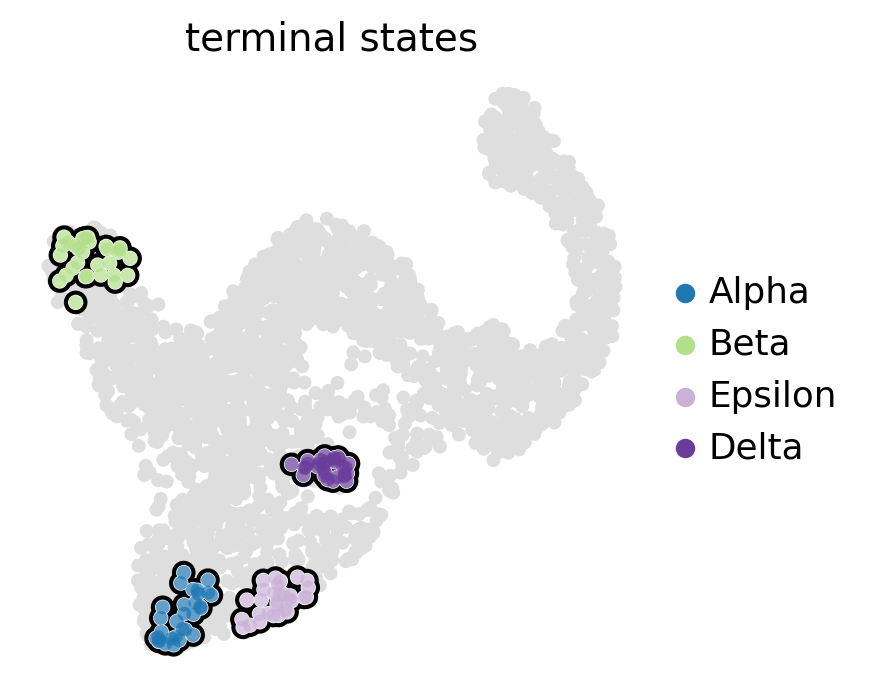

In [7]:
g.compute_macrostates(n_states=11, cluster_key="clusters")

g.set_terminal_states(states=["Alpha", "Beta", "Epsilon", "Delta"])
g.plot_macrostates(which="terminal", legend_loc="right", size=100)

## Estimate cellular fate bias

### Compute fate probabilities

We compute {attr}`~cellrank.estimators.GPCCA.fate_probabilities` by aggregating over all random walks that start in a given cell and end in some terminal population. There exists an analytical solution to this problem called [absorption probabilities](https://en.wikipedia.org/wiki/Absorbing_Markov_chain), their computation is 30x faster in CellRank 2 compared to version 1 and scales to millions of cells. 

INFO     Computing fate probabilities                                                                              


  0%|          | 0/4 [00:00<?, ?/s]

INFO     Adding `adata.obsm['lineages_fwd']`                                                                       
                `.fate_probabilities`                                                                              
             Finish (0.18s)                                                                                        


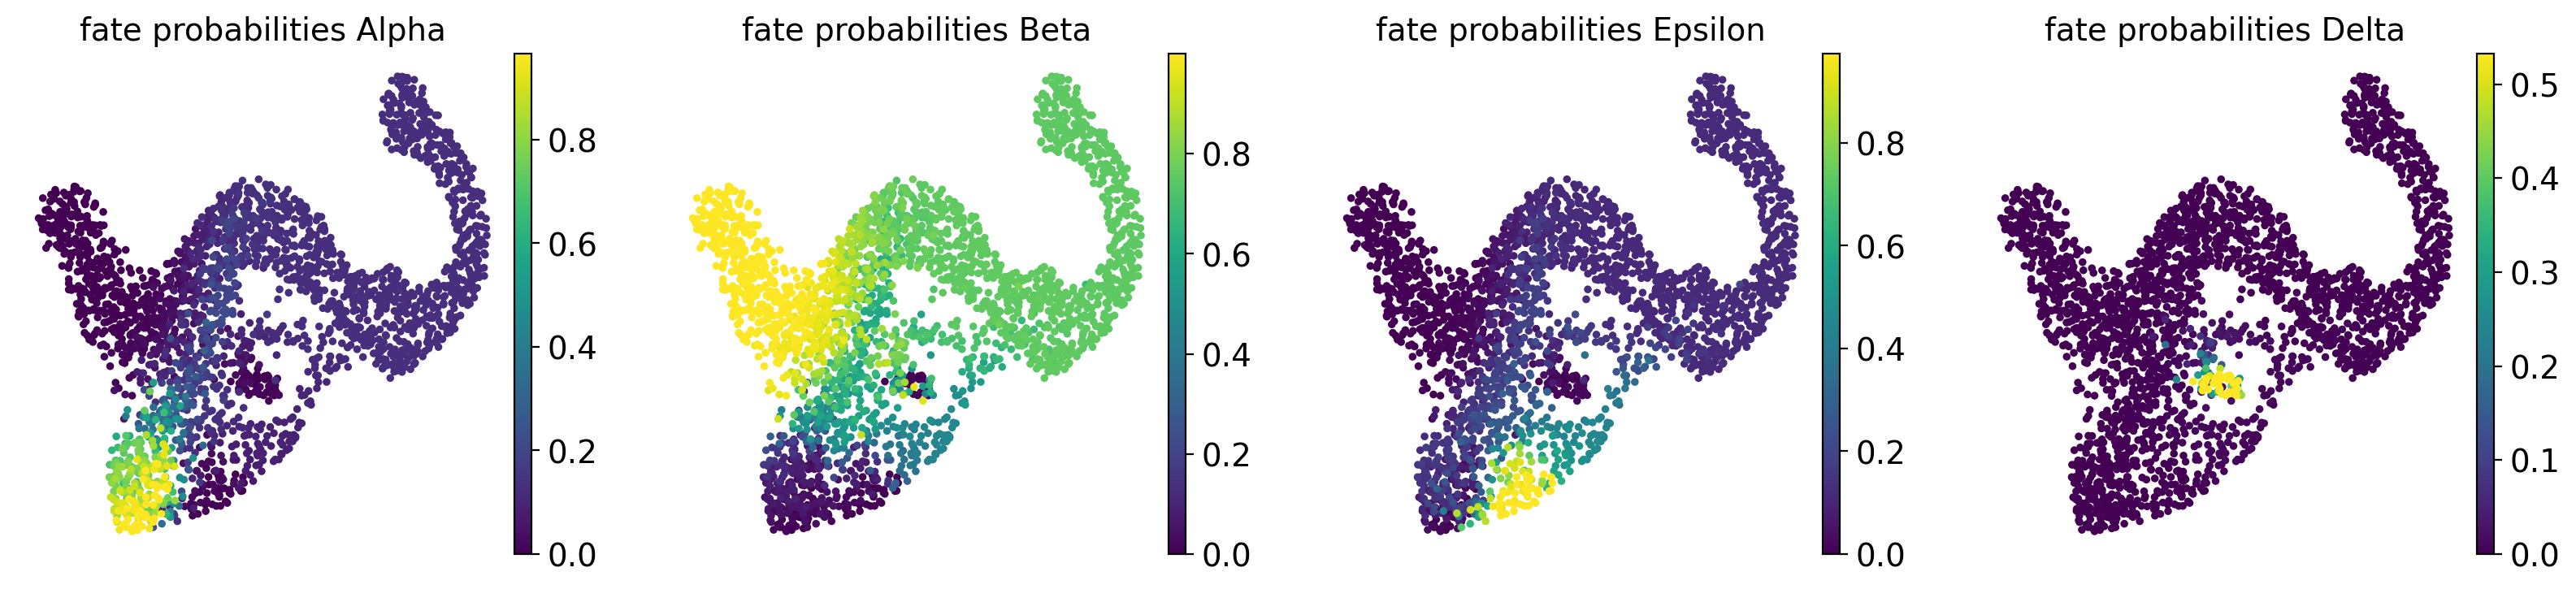

In [8]:
g.compute_fate_probabilities()
g.plot_fate_probabilities(same_plot=False)

Most cells appear to be fate-biased towards Beta cells, in agreement with known biology for mouse pancreas development at E15.5 {cite}`bastidas-ponce:19`. We can visualize these probabilities in compact form by coloring cells according to their most-likely fate, with color intensity reflecting the degree of lineage-bias by using {meth}`~cellrank.estimators.GPCCA.plot_fate_probabilities`. 

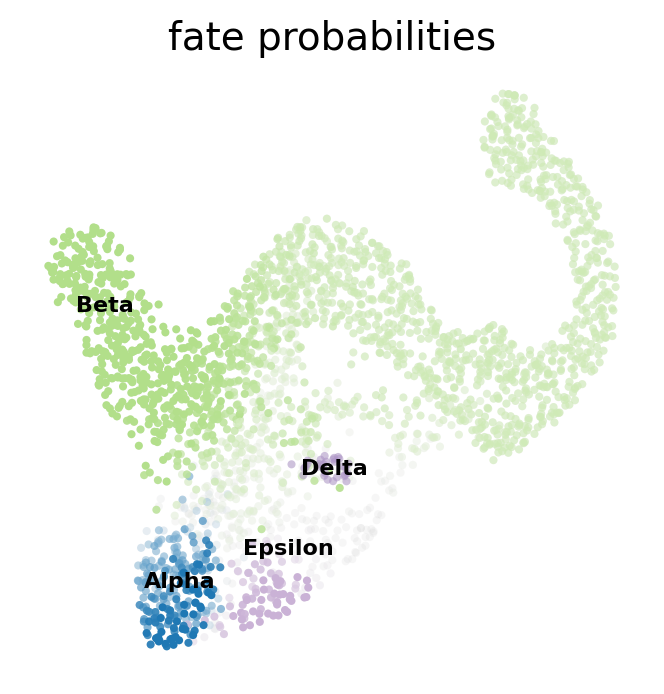

In [9]:
g.plot_fate_probabilities(same_plot=True)

Another compact way to simultanesosly visualize fate probabilities towards several terminal states is via {func}`cirular projections <cellrank.pl.circular_projection>` {cite}`velten:17`. In such a plot, we arrange all terminal states around a unit circle and place cells inside this circle, with a position determined by their fate probabilities. 

INFO     Solving TSP for `4` states                                                                                


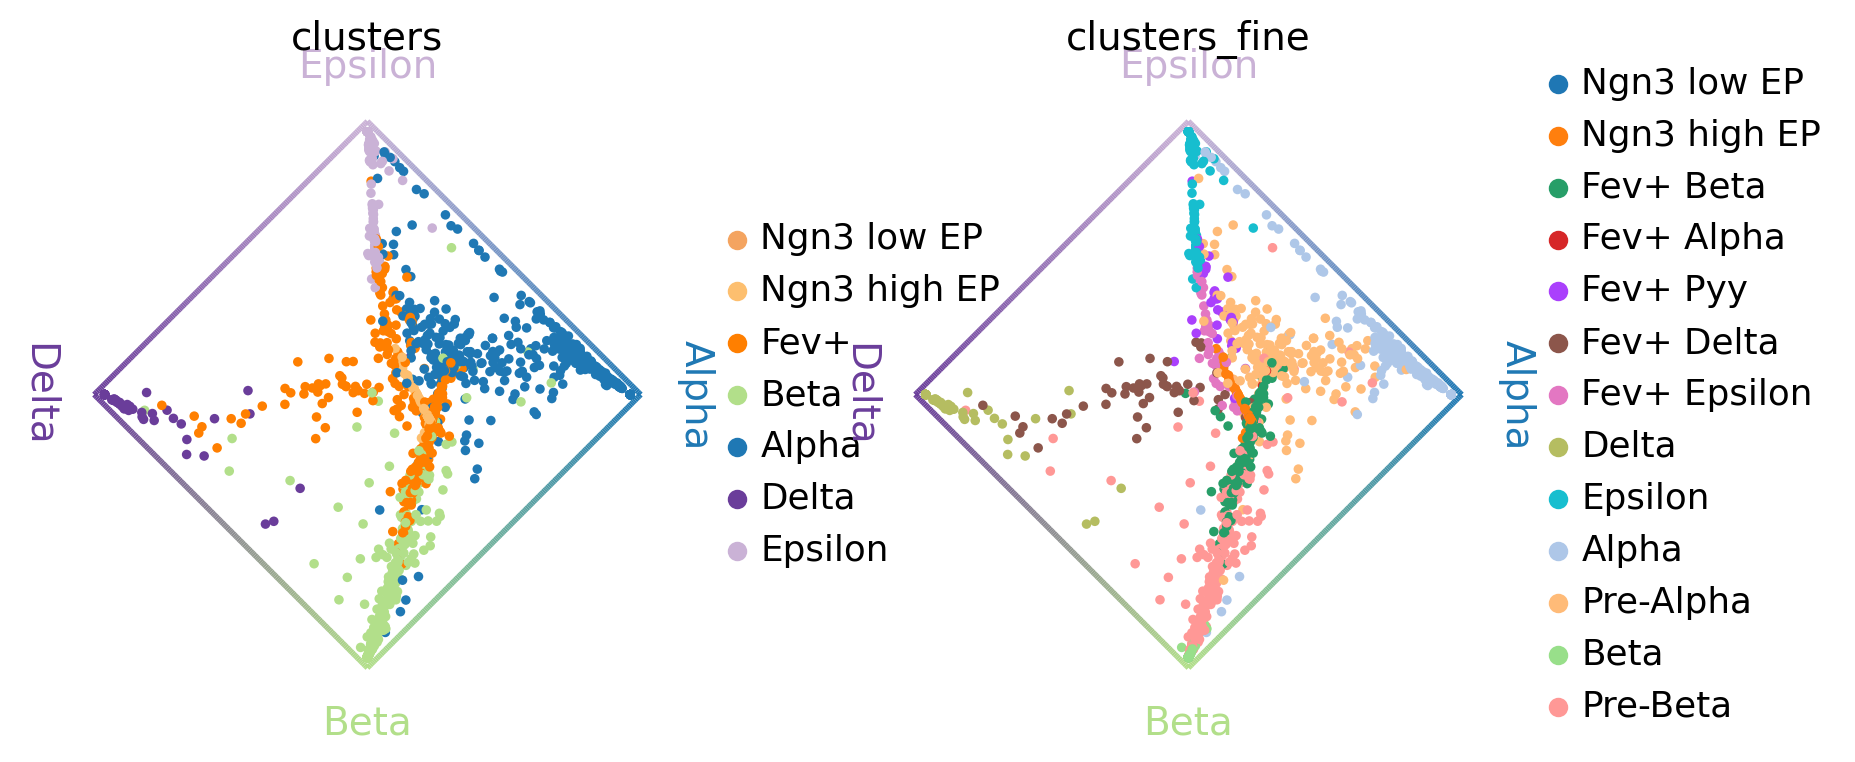

In [10]:
cr.pl.circular_projection(adata, keys=["clusters", "clusters_fine"], legend_loc="right")

**Left plot**: As expected, the algorithm placed more commited cells (Alpha, Beta, etc. ) closer to the edges and less commited cells (Ngn3 low EP, Fev+, etc. ) closer to the middle of the circle.

**Right plot**: Here, we zoom into the Fev+ progenitor population using a subclustering from the original publication {cite}`bastidas-ponce:19`. As expected, each Fev+ subpopulation is placed closer to its corresponding terminal state. 

### Aggregate fate probabilities

Often, we are interested in {func}`aggregated fate probabilities <cellrank.pl.aggregate_fate_probabilities>` over a group of cells, like a cell- type or state. As an example, let's focus on the Fev+ progenitor populations, and their fate commitment towards Delta cells. Let's start with an overview of these subpopulations. 

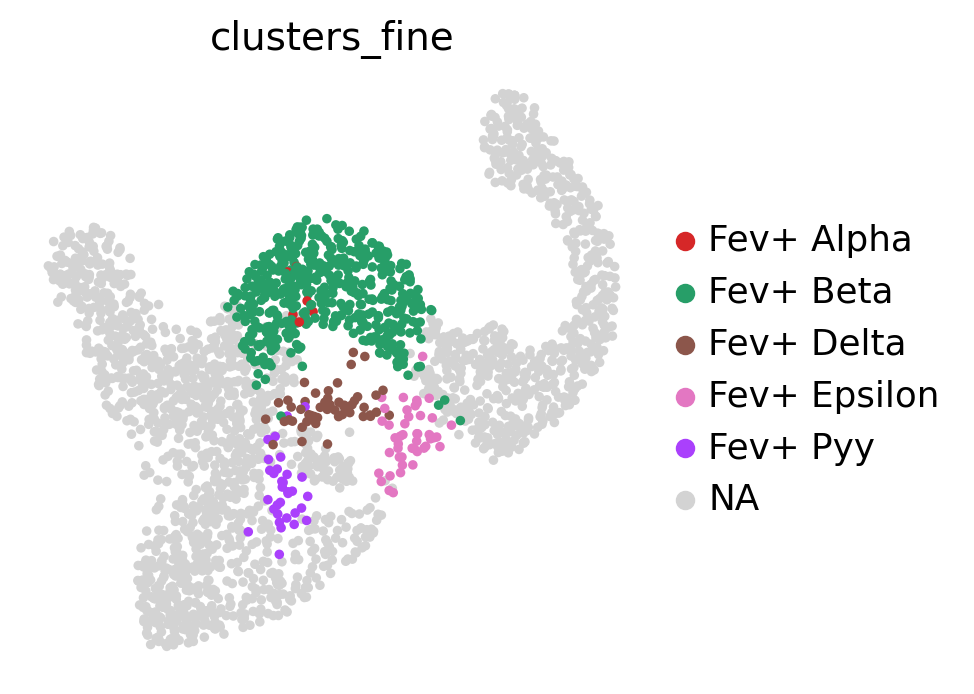

In [11]:
fev_states = ["Fev+ Beta", "Fev+ Alpha", "Fev+ Pyy", "Fev+ Delta", "Fev+ Epsilon"]
sc.pl.embedding(
    adata,
    basis="umap",
    color="clusters_fine",
    groups=fev_states,
    legend_loc="right margin",
)

Using violin plots, we visualize how fate-commited each of these populations is towards Delta cells. 

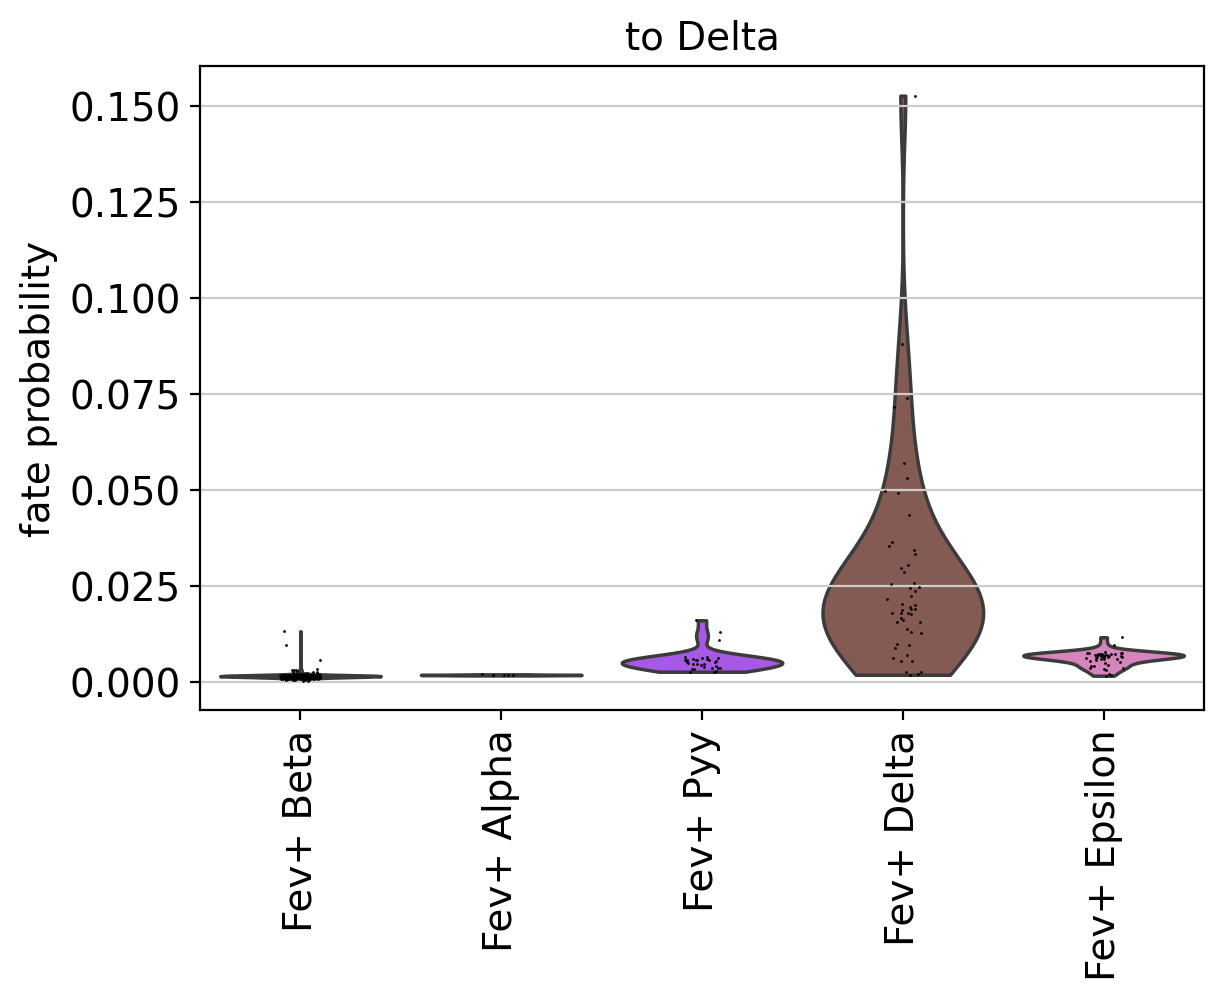

In [12]:
cr.pl.aggregate_fate_probabilities(
    adata,
    mode="violin",
    lineages=["Delta"],
    cluster_key="clusters_fine",
    clusters=fev_states,
)

As expected, Fev+ Delta cells are most commited towards Delta cells. CellRank supports many more ways to visualize aggregated fate probabilities, for example via heatmaps, bar plots, or paga-pie charts, see the {func}`API <cellrank.pl.aggregate_fate_probabilities>`. 

Let's look at another plotting possibility - pie charts arranged in a PAGA plot. We first need to compute PAGA using scanpy {cite}`wolf:19`. 

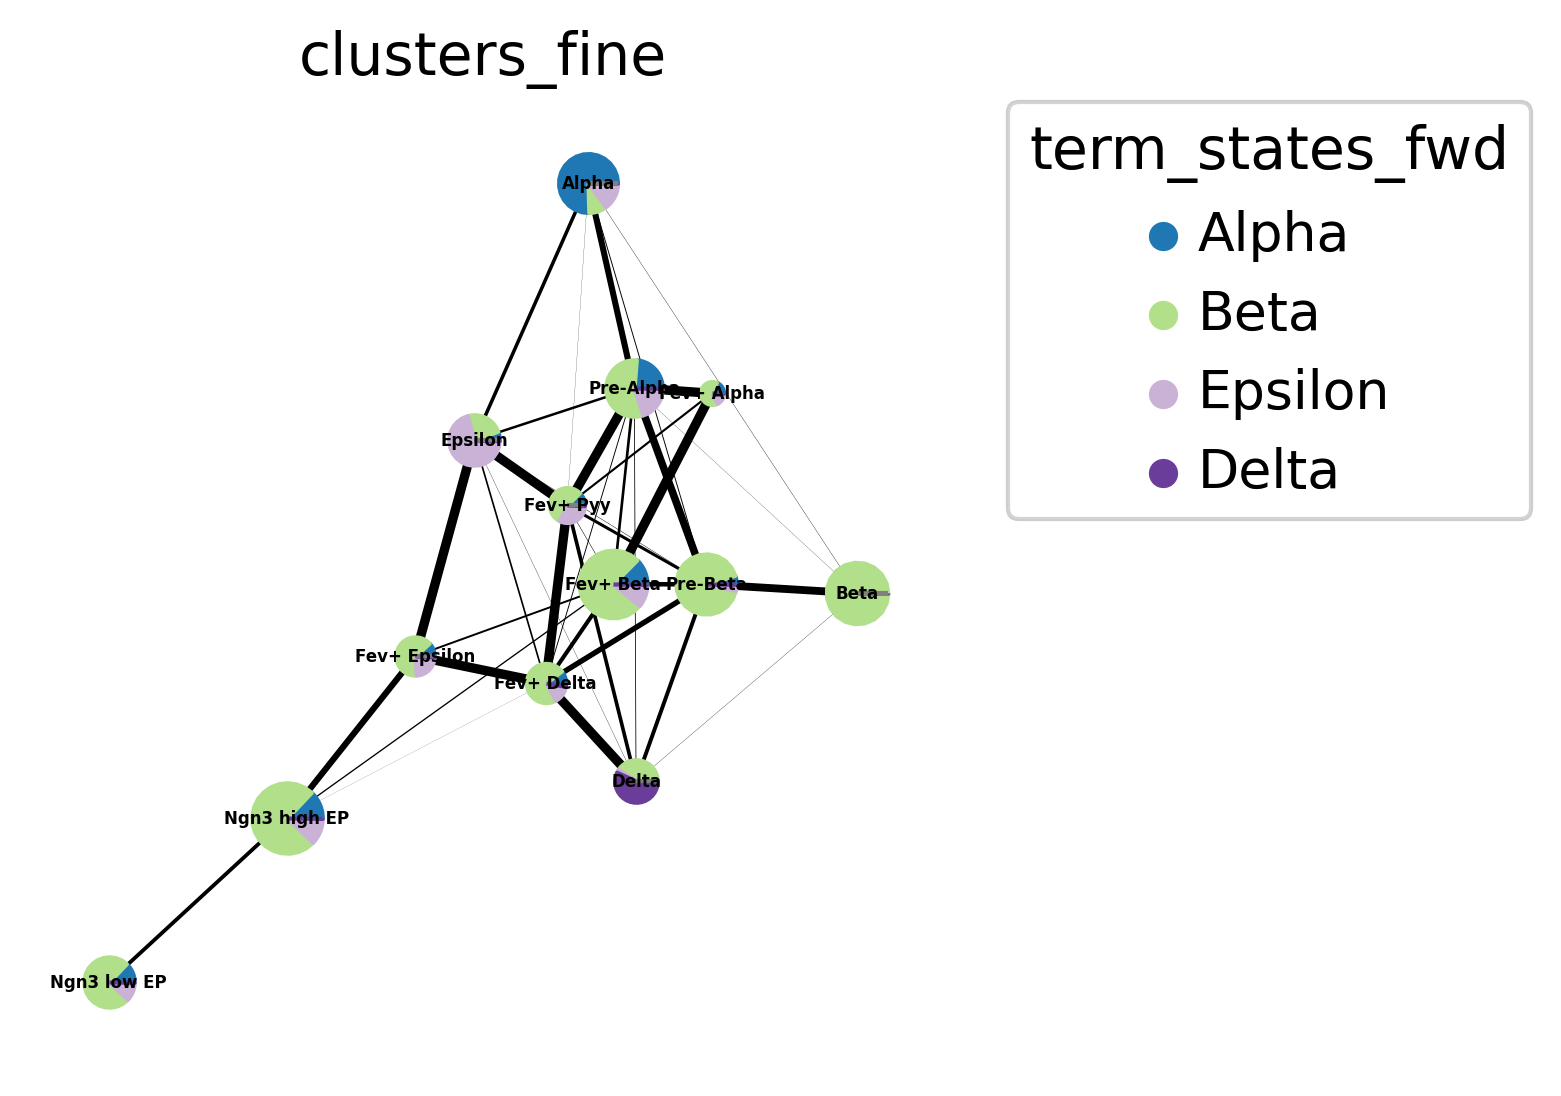

In [13]:
sc.tl.paga(adata, groups="clusters_fine")

cr.pl.aggregate_fate_probabilities(
    adata,
    mode="paga_pie",
    cluster_key="clusters_fine",
    legend_kwargs={"loc": "upper right out"},
    fontsize=4,
    edge_width_scale=0.3,
    dpi=150,
)

## Uncover driver genes

### Correlate fate probabilities with gene expression

We uncover putative driver genes by correlating fate probabilities with gene expression using the {meth}`~cellrank.estimators.GPCCA.compute_lineage_drivers` method. In other words, if a gene is systematically higher or lower expressed in cells that are more or less likely to differentiate towards a given terminal states, respectively, then we call this gene a putative driver gene. 

As an example, let's focus on Delta cell generation again, and let's restrict the correlation-computation to the relevant clusters. 

In [14]:
driver_clusters = ["Delta", "Fev+", "Ngn3 high EP", "Ngn3 low EP"]

delta_df = g.compute_lineage_drivers(
    lineages=["Delta"], cluster_key="clusters", clusters=driver_clusters
)
delta_df.head(10)

INFO     Adding `adata.varm['terminal_lineage_drivers']`                                                           
                `.lineage_drivers`                                                                                 
             Finish (0.05s)                                                                                        


,Delta_corr,Delta_pval,Delta_qval,Delta_ci_low,Delta_ci_high
index,,,,,
Sst,0.837618,0.000000e+00,0.000000e+00,0.820782,0.852999
Iapp,0.734253,1.101395e-254,3.285461e-251,0.708401,0.758137
Arg1,0.585548,2.595248e-131,5.161082e-128,0.548993,0.619867
Frzb,0.548492,4.214793e-111,6.286364e-108,0.509679,0.585077
Pyy,0.530892,1.761956e-102,2.102366e-99,0.491063,0.568505
Rbp4,0.509664,7.963936e-93,7.918807e-90,0.468659,0.548478
Hhex,0.498949,3.079578e-88,2.624680e-85,0.457370,0.538352
1500009L16Rik,0.490320,1.125453e-84,8.393066e-82,0.448288,0.530189
Fam159b,0.482760,1.202135e-81,7.968816e-79,0.440338,0.523030


This computed correlation values, as well as p-values, multiple-testing corrected q-values, and confidence intervals.

### Visualize putative driver genes

We can visually explore a few of these genes identified above. 

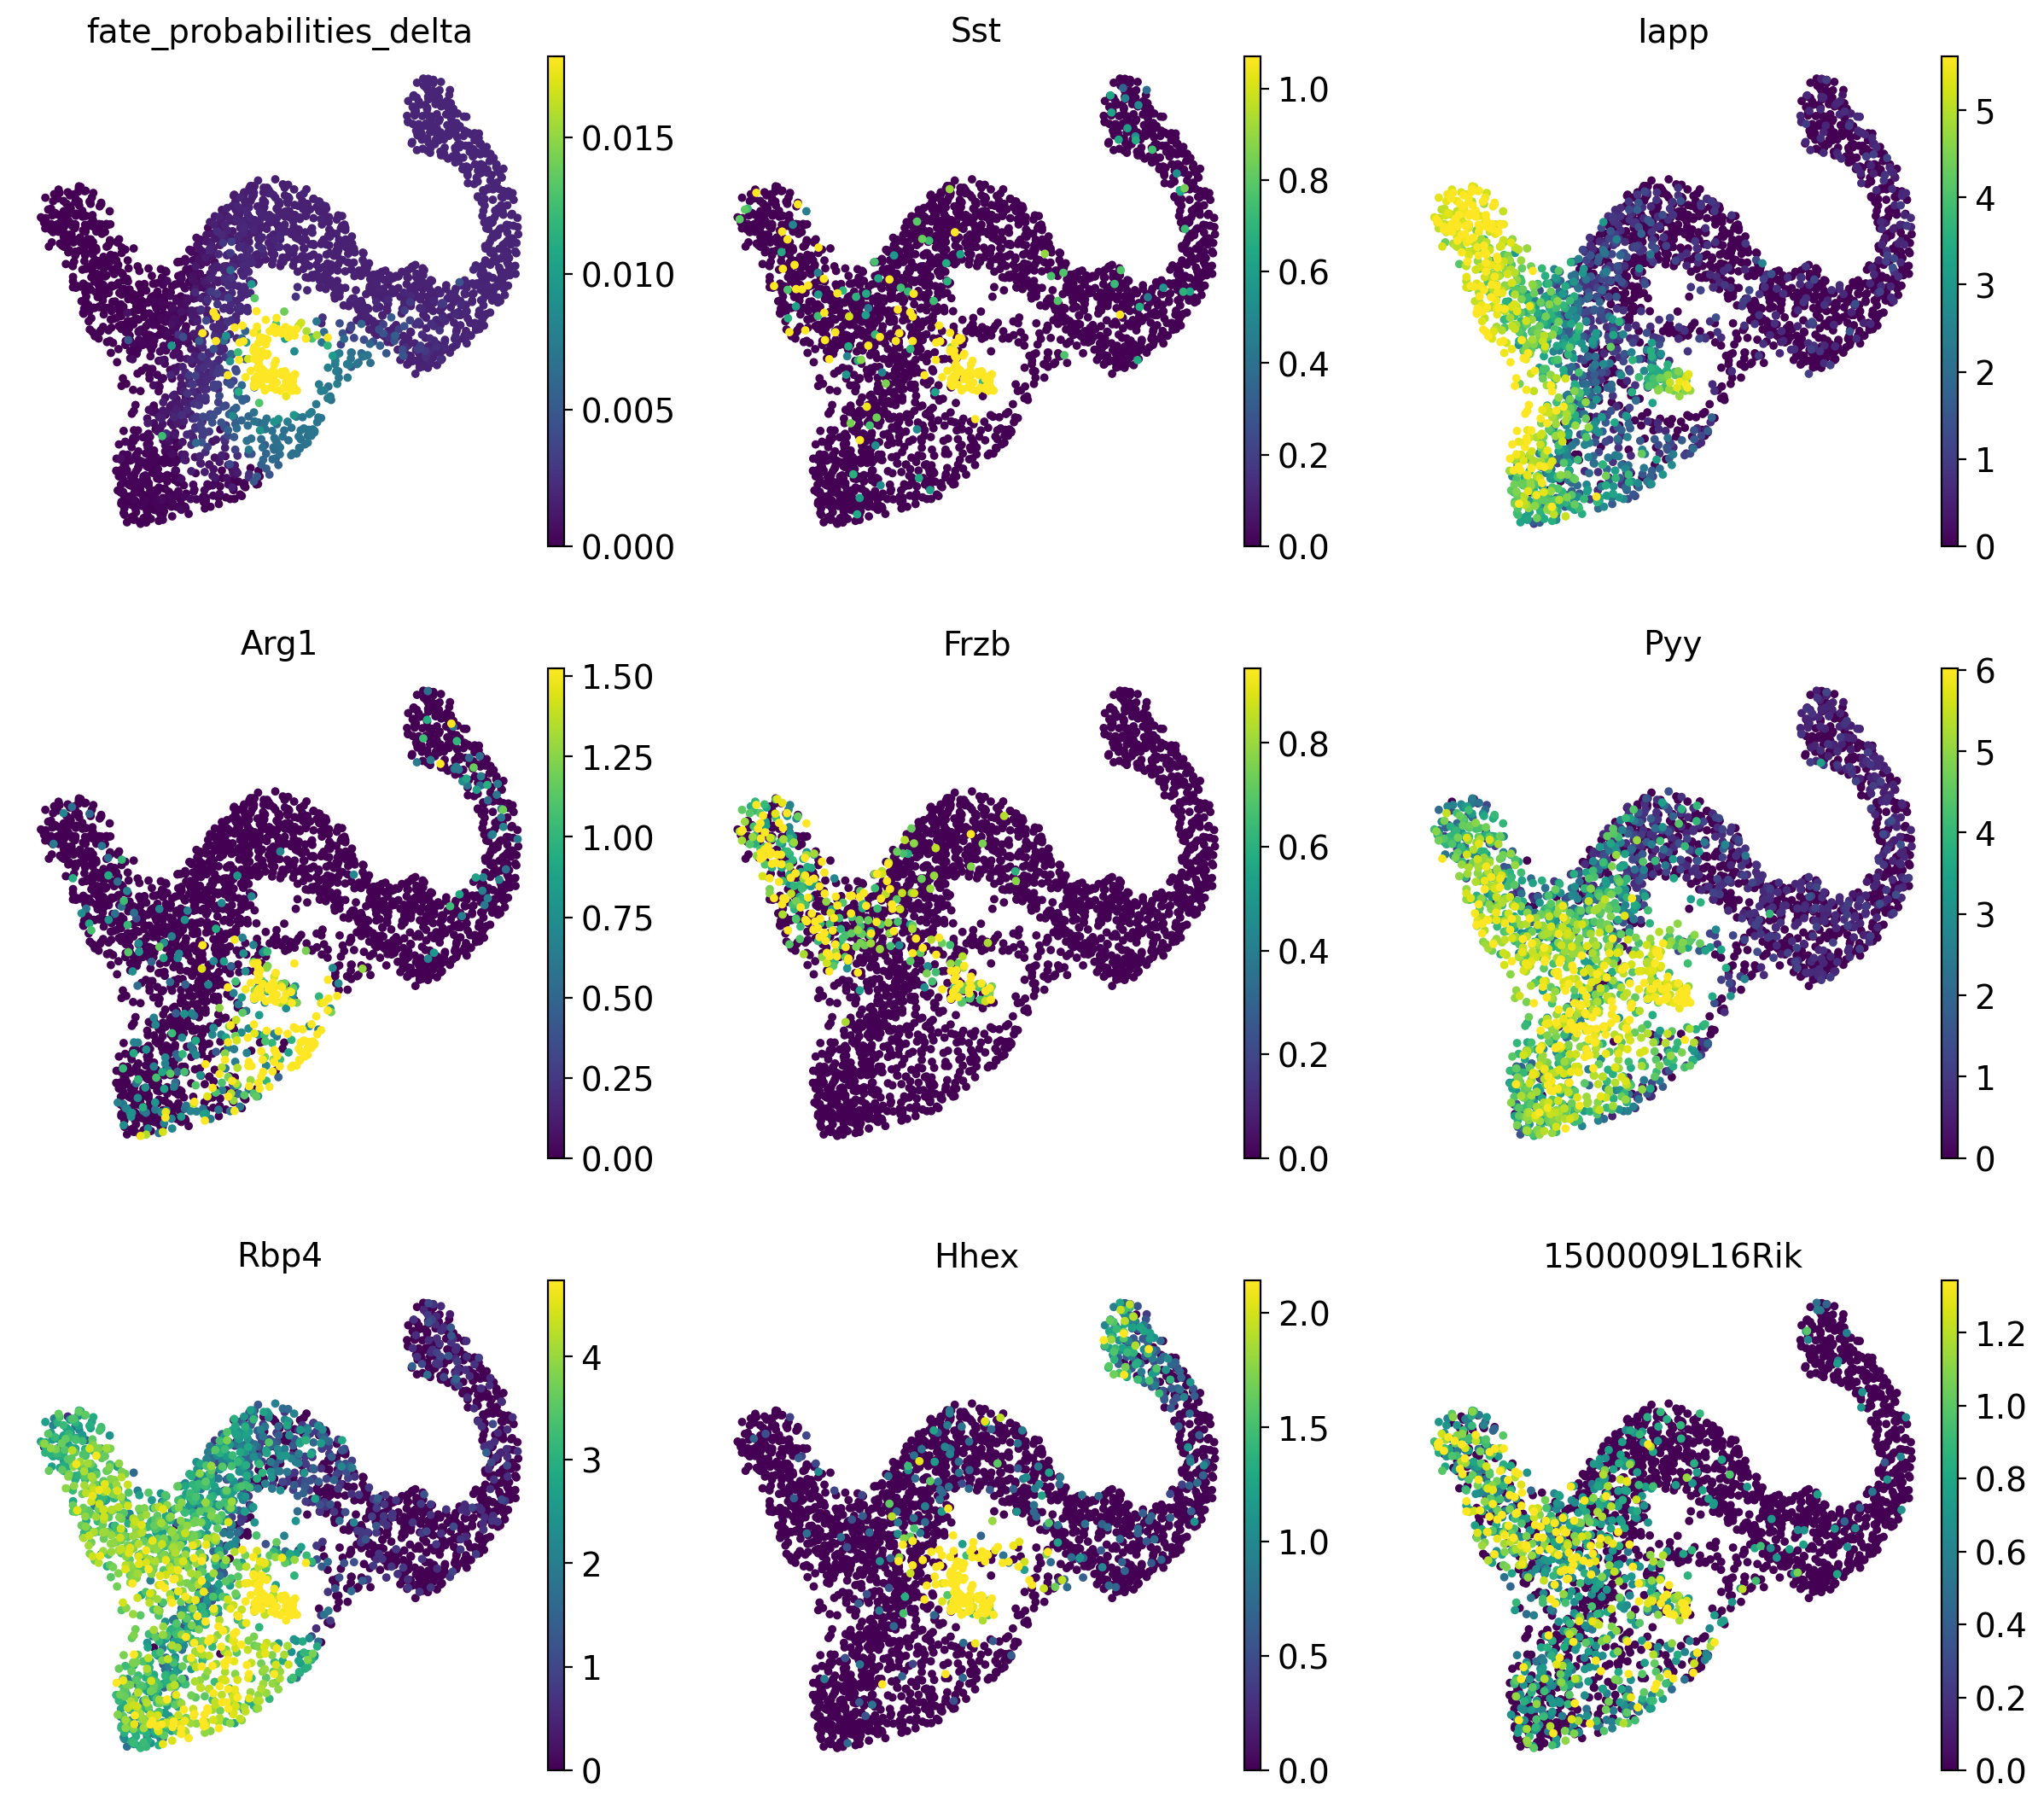

In [15]:
adata.obs["fate_probabilities_delta"] = g.fate_probabilities["Delta"].X.flatten()

sc.pl.embedding(
    adata,
    basis="umap",
    color=["fate_probabilities_delta"] + list(delta_df.index[:8]),
    color_map="viridis",
    s=50,
    ncols=3,
    vmax="p96",
)

We show fate probabilities towards the Delta population and some of the top-correlating genes. Among them are Somatostatin (*Sst*; the hormone produced by Delta cells) and the homeodomain transcription factor *Hhex* (hematopoietically expressed homeobox), a known driver gene for Delta cell generation {cite}`zhang:14`. 

Beyond Delta cells, let's compute driver genes for all trajectories, and let's visualize some of the top-correlating genes for the Alpha and Beta lineages using {meth}`~cellrank.estimators.GPCCA.plot_lineage_drivers_correlation`. 

INFO     Adding `adata.varm['terminal_lineage_drivers']`                                                           
                `.lineage_drivers`                                                                                 
             Finish (0.12s)                                                                                        
INFO     Adjusting text position                                                                                   
INFO         Finish (1.08s)                                                                                        


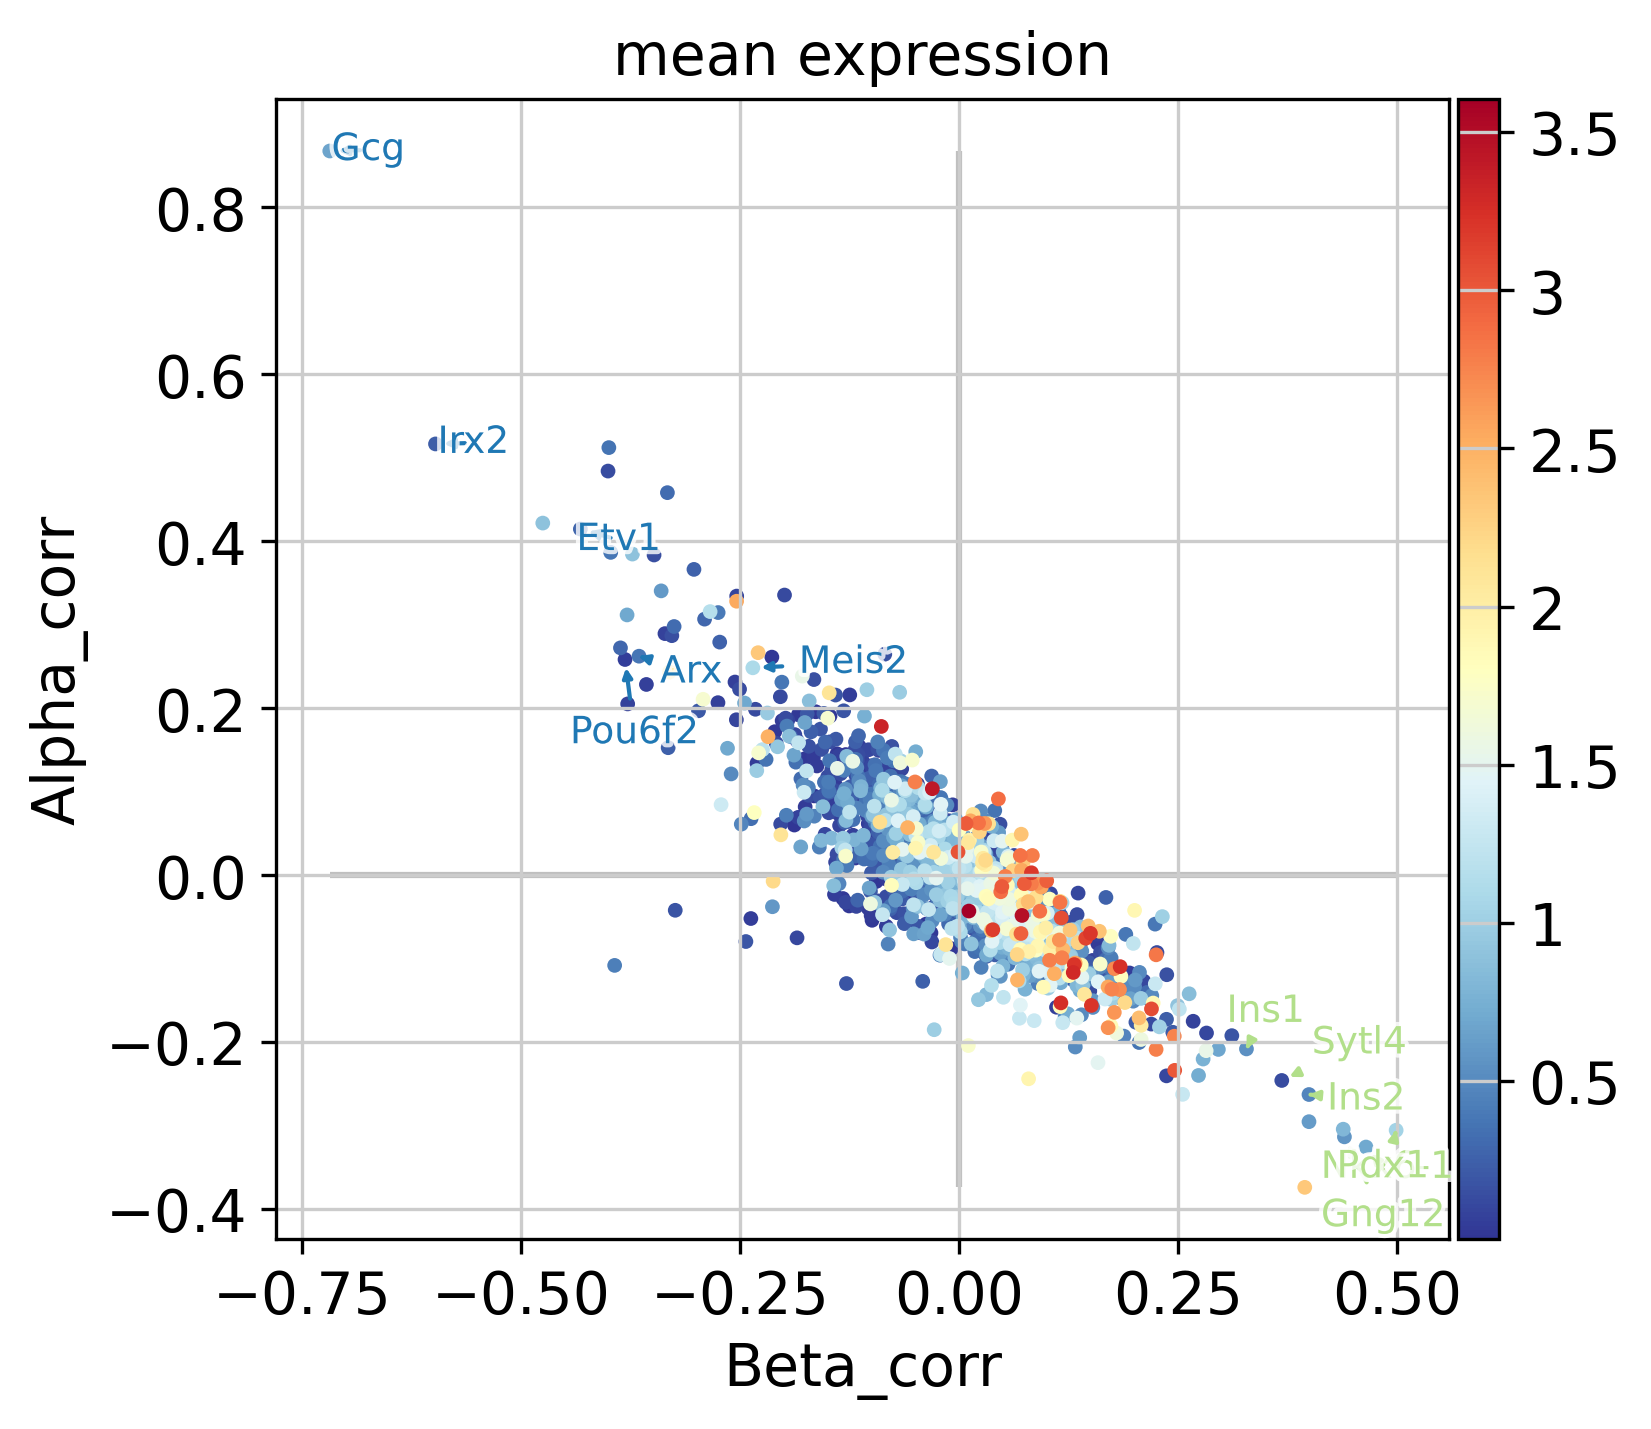

In [16]:
# compute driver genes
driver_df = g.compute_lineage_drivers()

# define set of genes to annotate
alpha_genes = ["Arx", "Gcg", "Irx2", "Etv1", "Pou6f2", "Meis2"]
beta_genes = ["Ins2", "Gng12", "Ins1", "Nkx6-1", "Pdx1", "Sytl4"]

genes_oi = {
    "Alpha": alpha_genes,
    "Beta": beta_genes,
}

# make sure all of these exist in AnnData
assert [gene in adata.var_names for genes in genes_oi.values() for gene in genes], (
    "Did not find all genes"
)

# compute mean gene expression across all cells
adata.var["mean expression"] = np.asarray(adata.X.mean(axis=0)).flatten()

# visualize in a scatter plot
g.plot_lineage_drivers_correlation(
    lineage_x="Beta",
    lineage_y="Alpha",
    adjust_text=True,
    gene_sets=genes_oi,
    color="mean expression",
    legend_loc="none",
    figsize=(5, 5),
    dpi=150,
    fontsize=9,
    size=50,
)

In the plot above, each dot represents a gene, colored by mean expression across all cells, with Beta- and Alpha correlations on the x- and y-axis, respectively. As expected, these two are anti-correlated; genes that correlate positively with the Alpha fate correlate negatively with the Beta fate and vice versa. We annotate a few transciption factors (TFs; according to https://www.ncbi.nlm.nih.gov/) with known functions in Beta-or Alpha trajectories, all of which are among the top-30 highest correlated genes: 

| Gene Name | Reference                                     | Trajectory |
|-----------|-----------------------------------------------|------------|
| Arx       | PMID: 32149367, PMID: 23785486, PMID: 24236044 | Alpha     |
| Irx2      | PMID: 26977395                                | Alpha      |
| Etv1      | PMID: 32439909                                | Alpha      |
| Gng12     | PMID: 30254276                                | Beta       |
| Nkx6-1    | PMID: 33121533, PMID: 34349281                | Beta       |
| Pdx1      | PMID: 31401713, PMID: 33526589, PMID: 28580283 | Beta      |
| Sytl4     | PMID: 27032672, PMID: 12058058                | Beta       |

Further, we annotate *Gcg*, the gene encoding the Alpha cell hormone Glucagon, as well as *Ins1* and *Ins2*, the genes encoding the Beta cell hormone Insulin. We also annotate *Pou6f2* and *Meis2*, two TFs which are highly correlated with the Alpha fate probabilities, with no known function in Alpha cell formation or maintenance, to the best of our knowledge. These serve as examples of how fate probabilities can be used to predict putative new driver genes. 

## Closing matters

### What's next? 

In this tutorial, you learned how to compute, aggregate and visualize fate probabilities and predict driver genes. For the next steps, we recommend to: 

- go through the {doc}`gene trend plotting tutorial <800_gene_trends>` to learn how to visulize gene dynamics in pseudotime.
- take a look at the {class}`API <cellrank.estimators.GPCCA>` to learn about parameters you can use to adapt these computations to your data. 
- try this out on your own data. 

### Package versions

In [17]:
session_info2.session_info()

Package,Version
pandas,2.3.3
cellrank,2.1.1.dev37+gbe689eb39.d20260305
numpy,2.1.3
scanpy,1.12
anndata,0.12.10
Component,Info
Python,"3.12.12 | packaged by conda-forge | (main, Jan 26 2026, 23:51:32) [GCC 14.3.0]"
OS,Linux-5.15.0-171-generic-x86_64-with-glibc2.35
Updated,2026-03-09 13:20
Dependency,Version
